# **Depression Prediction using XGBoost**

## 1. Project Objective
The goal of this project is to build a robust machine learning model to predict the likelihood of depression based on a preprocessed dataset. **XGBoost** will be empluyed, a powerful gradient boosting algorithm known for its performance on structured data.

## 2. Methodology
To ensure model reliability and performance, this notebook follows these steps:
1.  **Data Preparation:** Loading preprocessed data and encoding categorical variables.
2.  **Hyperparameter Optimization:** Using **Optuna** to find the optimal set of hyperparameters (learning rate, depth, regularization) to maximize the AUC score.
3.  **Model Evaluation:** Implementing **K-Fold Cross-Validation** to assess the model's stability and generalization capability.

# **Libraries**

In [ ]:
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# **Load and Prepare Data**

In [2]:
# Load preprocessed datasets
train_df = pd.read_csv('train_preprocessed.csv')
test_df = pd.read_csv('test_preprocessed.csv')

# Prepare data for training
drop_cols = ['id', 'Name']
X = train_df.drop(columns=drop_cols + ['Depression'])
y = train_df['Depression']
X_test = test_df.drop(columns=drop_cols)

# Identify categorical columns (object type)
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Encode categorical variables
combined = pd.concat([X, X_test], axis=0)

for col in cat_cols:
    le = LabelEncoder()
    # Convert to string to handle potential mixed types
    combined[col] = le.fit_transform(combined[col].astype(str))

# Split back into train and test
X = combined.iloc[:len(X)]
X_test = combined.iloc[len(X):]

# Split training data for validation (80% train, 20% validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=607)

Training Data Shape: (140700, 17)
Testing Data Shape: (93800, 16)


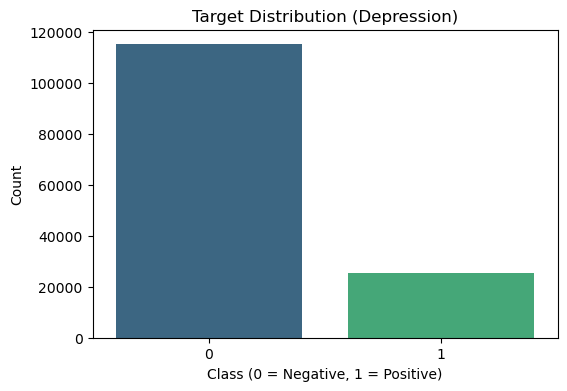

Depression
0    0.818287
1    0.181713
Name: proportion, dtype: float64


In [9]:
# Quick overview of the data
print(f"Training Data Shape: {train_df.shape}")
print(f"Testing Data Shape: {test_df.shape}")

# Visualizing Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y, hue=y, palette='viridis', legend=False)
plt.title('Target Distribution (Depression)')
plt.xlabel('Class (0 = Negative, 1 = Positive)')
plt.ylabel('Count')
plt.show()

# Check ratio
print(y.value_counts(normalize=True))

# **Model Training**

## 3. Hyperparameter Tuning with Optuna
Using Bayesian optimization via Optuna to tune the XGBoost hyperparameters. The key parameters being optimized are:

* **Learning Rate ($\eta$):** Controls the step size at each iteration while moving toward a minimum of a loss function.
* **Max Depth:** Controls the maximum depth of a tree. Increasing this value will make the model more complex and more likely to overfit.
* **Reg Alpha ($\alpha$) & Reg Lambda ($\lambda$):** L1 and L2 regularization terms on weights. Increasing this value will make model more conservative.
* **Gamma ($\gamma$):** Minimum loss reduction required to make a further partition on a leaf node of the tree.

In [4]:
def objective(trial):
    colsample_bytree= trial.suggest_float('colsample_bytree',0,1)
    n_estimators = trial.suggest_int('n_estimators', 400,1000)
    learning_rate = trial.suggest_float('learning_rate', 0.01,0.1)
    reg_lambda = trial.suggest_float('reg_lambda', 0,4)
    reg_alpha = trial.suggest_float('reg_alpha', 0,4)
    max_depth = trial.suggest_int('max_depth', 2,10)
    gamma = trial.suggest_float('gamma', 0,0.5)
    eval_metric='auc'
    
    model = XGBClassifier(
    colsample_bytree = colsample_bytree,
    n_estimators=n_estimators,
    learning_rate=learning_rate,
    max_depth=max_depth,
    reg_alpha=reg_alpha,
    reg_lambda=reg_lambda,
    gamma=gamma,
    eval_metric='auc',
    random_state=607
)
    model.fit(X_train, y_train)
    score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    return score

In [5]:
study = optuna.create_study(direction='maximize',sampler=optuna.samplers.RandomSampler(seed=607))
optuna.logging.set_verbosity(optuna.logging.WARNING)

def log_best_trial(study, trial):
    if study.best_trial == trial:
        print(f"New best trial: {trial.number} with value: {trial.value} and params: {trial.params}")

study.optimize(objective, n_trials=100,callbacks=[log_best_trial])

[I 2025-11-26 15:30:48,126] A new study created in memory with name: no-name-863fae1c-016a-43a3-afff-049ec2f55378


New best trial: 0 with value: 0.9684588377662676 and params: {'colsample_bytree': 0.9241441149445456, 'n_estimators': 480, 'learning_rate': 0.01934695515938726, 'reg_lambda': 0.995746986500277, 'reg_alpha': 0.7922495581786353, 'max_depth': 3, 'gamma': 0.00960148482380424}
New best trial: 1 with value: 0.9693897518039827 and params: {'colsample_bytree': 0.1621141939217663, 'n_estimators': 866, 'learning_rate': 0.01830911692556304, 'reg_lambda': 2.9106714720433975, 'reg_alpha': 2.3081746881941307, 'max_depth': 8, 'gamma': 0.2014396057468147}
New best trial: 2 with value: 0.970246015987167 and params: {'colsample_bytree': 0.8807953818921426, 'n_estimators': 412, 'learning_rate': 0.0758420999774204, 'reg_lambda': 0.7061383279618365, 'reg_alpha': 2.210813909235981, 'max_depth': 3, 'gamma': 0.36577013322844903}
New best trial: 3 with value: 0.970634778359344 and params: {'colsample_bytree': 0.14492566230028125, 'n_estimators': 714, 'learning_rate': 0.0638419910172031, 'reg_lambda': 0.7995410

In [6]:
best_params = study.best_params
best_score = study.best_value
print(f"Best Hyperparameters: {best_params}")
print(f"Best Accuracy: {best_score:.6f}")

n_estimators = best_params['n_estimators']
reg_alpha = best_params['reg_alpha']
learning_rate = best_params['learning_rate']
reg_lambda = best_params['reg_lambda']
max_depth = best_params['max_depth']
colsample_bytree = best_params['colsample_bytree']
gamma = best_params['gamma']

Best Hyperparameters: {'colsample_bytree': 0.18491948189624074, 'n_estimators': 776, 'learning_rate': 0.0677690926245392, 'reg_lambda': 3.8090709567598484, 'reg_alpha': 1.8658234132441454, 'max_depth': 5, 'gamma': 0.04122379987553004}
Best Accuracy: 0.970679


In [7]:
# Define parameters
xgb_model = XGBClassifier(
    colsample_bytree = colsample_bytree,
    n_estimators = n_estimators,
    learning_rate = learning_rate,
    reg_alpha = reg_alpha,
    reg_lambda = reg_lambda,
    max_depth = max_depth,
    gamma=gamma,
    eval_metric='auc',
    random_state=607
)

# K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

eval_set = [(X_train, y_train), (X_test, y_test)]

xgb_model.fit(X_train, y_train)

fold_accuracies = []

# Perform K-Fold Cross Validation
for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    xgb_model.fit(X_train, y_train)
    preds = xgb_model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    fold_accuracies.append(acc)

    print(f"--- Fold {fold} - Accuracy: {acc:.6f}")

# Summary
overall = np.mean(fold_accuracies)
std = np.std(fold_accuracies)

print(f"\n------ Overall: {overall:.6f} | Average: {overall:.6f} ± {std:.6f}")

# # Save results to a dataframe 
# submission = pd.DataFrame({
#     'id': test_df['id'],
#     'Name': test_df['Name'],
#     'Depression_Prediction': test_predictions
# })

# # Show the first few predictions
# print("\nSample Predictions on Test Data:")
# print(submission.head())

--- Fold 1 - Accuracy: 0.930597
--- Fold 2 - Accuracy: 0.929282
--- Fold 3 - Accuracy: 0.931450
--- Fold 4 - Accuracy: 0.934435
--- Fold 5 - Accuracy: 0.931592

------ Overall: 0.931471 | Average: 0.931471 ± 0.001694


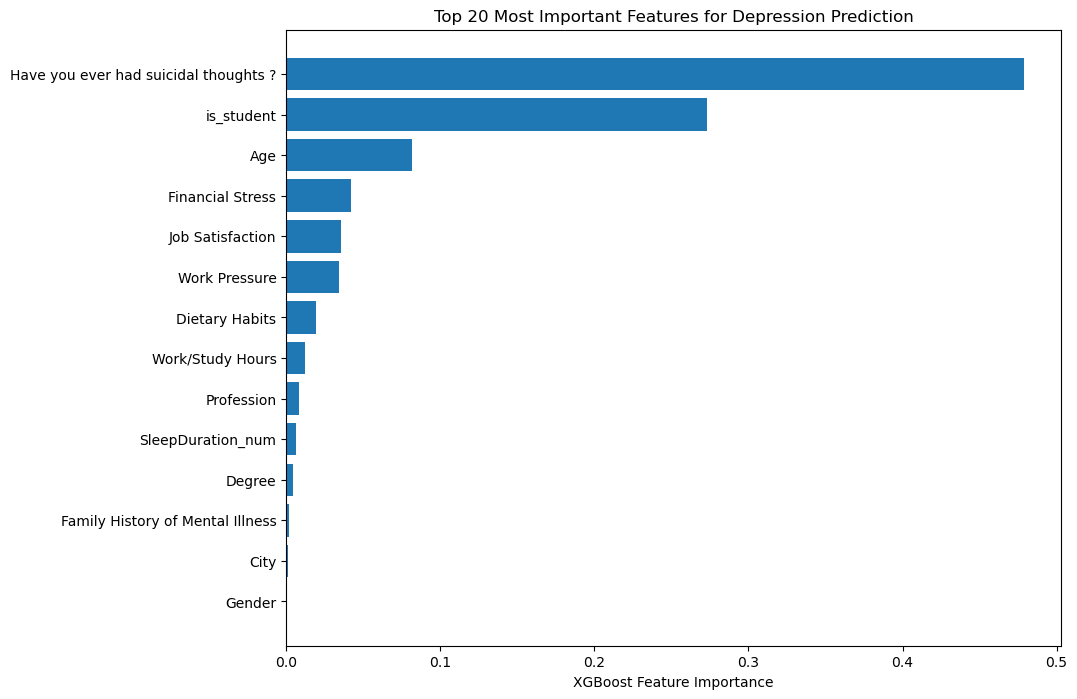

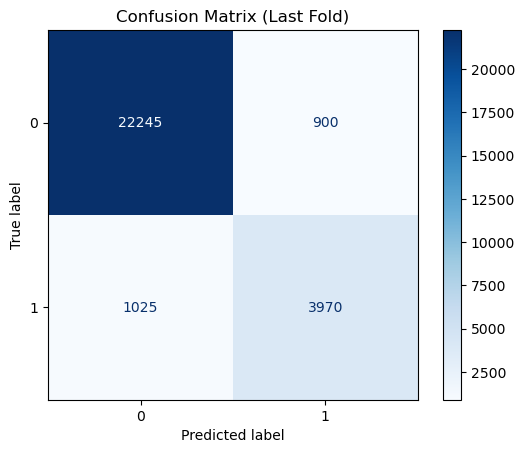

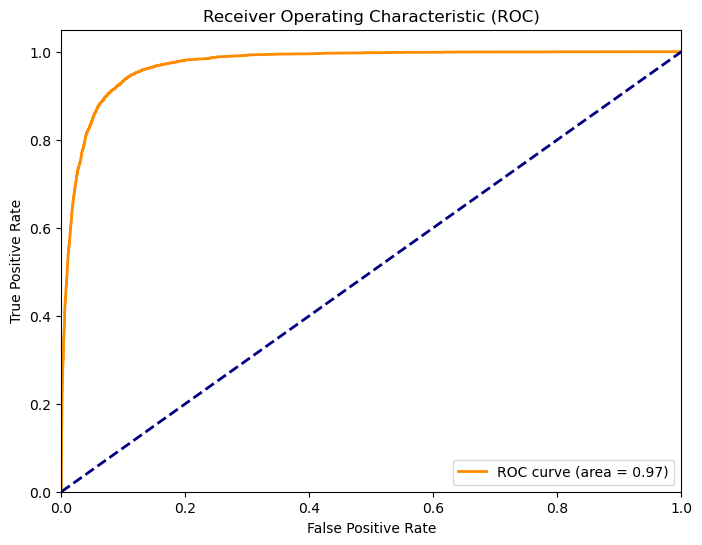

In [8]:
# --- 1. Feature Importance Visualization ---
# (Using the model from the last fold or refitting on full train set)
xgb_model.fit(X, y) # Refit on full data for final interpretation

plt.figure(figsize=(10, 8))
sorted_idx = xgb_model.feature_importances_.argsort()
plt.barh(X.columns[sorted_idx][-20:], xgb_model.feature_importances_[sorted_idx][-20:]) # Top 20 features
plt.xlabel("XGBoost Feature Importance")
plt.title("Top 20 Most Important Features for Depression Prediction")
plt.show()

# --- 2. Confusion Matrix ---
# Visualizing how the model performed on the last validation fold
cm = confusion_matrix(y_val, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Last Fold)")
plt.show()

# --- 3. ROC Curve ---
y_pred_proba = xgb_model.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

## 4. Conclusion and Next Steps

### Summary of Findings
* **Model Performance:** The XGBoost model achieved an average accuracy of **0.931471** across 5 folds, indicating stable performance.
* **Key Features:** As shown in the feature importance plot, the variables **Have you ever had sucidal thoughts** and **is_student** were the significant drivers in predicting depression.

### Future Work
To further improve the model:
1.  **Feature Engineering:** Creating interaction terms between the top features.
2.  **Ensembling:** Combining XGBoost with LightGBM or CatBoost to reduce variance.
3.  **Threshold Moving:** Adjusting the classification threshold to prioritize Recall or Precision depending on the medical use case.